In [1]:
# ==============================================================================
# COMPARATIVE STUDY: REGULARIZED CNN vs ResNet-18
# Indonesian Rupiah Banknote Classification
# ==============================================================================
# Notebook ini melatih DUA model secara berurutan menggunakan dataset dan
# hyperparameter yang IDENTIK, lalu membandingkan performa keduanya.
#
# Struktur notebook:
#   BLOK 1  - Import Library
#   BLOK 2  - Mount Google Drive
#   BLOK 3  - Konfigurasi Path Dataset
#   BLOK 4  - Split Dataset (Train/Val/Test)
#   BLOK 5  - Konfigurasi Hyperparameter
#   BLOK 6  - Data Augmentation & Preprocessing
#   BLOK 7  - Load Dataset dengan ImageFolder
#   BLOK 8  - Definisi Model CNN (Regularized CNN dari scratch)
#   BLOK 9  - Definisi Model ResNet-18 (Fine-tuned, pretrained ImageNet)
#   BLOK 10 - Fungsi Training Universal (dipakai kedua model)
#   BLOK 11 - Training Model CNN
#   BLOK 12 - Training Model ResNet-18
#   BLOK 13 - Evaluasi Final Kedua Model (Test Set)
#   BLOK 14 - Visualisasi Training Curve Perbandingan
#   BLOK 15 - Confusion Matrix Kedua Model
#   BLOK 16 - Tabel Ringkasan Perbandingan Performa
#   BLOK 17 - Simpan Model Final
# ==============================================================================


In [6]:
# ==============================================================================
# BLOK 1: IMPORT LIBRARY
# ==============================================================================
# Library standar Python untuk operasi file, sistem, dan randomisasi
import os
import shutil
import random
import time

# Library untuk progress bar visual dan operasi array
from tqdm import tqdm
import numpy as np

# PyTorch: framework deep learning utama
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Torchvision: dataset, transformasi gambar, dan model pretrained (ResNet-18)
from torchvision import datasets, transforms, models

# Scikit-learn: evaluasi model (classification report, confusion matrix, accuracy)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Google Colab: mount Google Drive untuk akses dataset
# from google.colab import drive

# Matplotlib & Seaborn: visualisasi grafik training curve dan confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns




In [ ]:
# ==============================================================================
# BLOK 3: KONFIGURASI PATH DATASET
# ==============================================================================
# Path sumber: folder dataset asli yang sudah diorganisir per kelas
# Struktur: SOURCE_DIR/{nama_kelas}/*.jpg
SOURCE_DIR = "./datasetBN"

# Path tujuan: folder hasil split (train/val/test) akan disimpan di sini
# Folder ini akan dibuat ulang setiap kali untuk memastikan data fresh
SPLIT_DIR = "./datasetBN_Split"

# Path untuk menyimpan semua output eksperimen (model, grafik, hasil)
OUTPUT_DIR = "./hasil_komparasi"
os.makedirs(OUTPUT_DIR, exist_ok=True)




In [ ]:
# ==============================================================================
# BLOK 4: SPLIT DATASET (TRAIN/VAL/TEST)
# ==============================================================================
# Rasio pembagian dataset mengacu pada metodologi paper:
#   - Train : 70% untuk training model
#   - Val   : 15% untuk monitoring & early stopping
#   - Test  : 15% untuk evaluasi akhir yang tidak bias
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Random seed untuk reproducibility (hasil split sama setiap kali dijalankan)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Hapus folder split lama jika ada, lalu buat ulang struktur direktori
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in ['train', 'val', 'test']:
    for cls in os.listdir(SOURCE_DIR):
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

# Proses split per kelas (stratified: proporsi kelas terjaga di semua split)
for cls in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, cls)
    if not os.path.isdir(class_path):
        continue

    # Ambil semua file gambar di folder kelas ini
    images = os.listdir(class_path)

    # Acak urutan gambar agar distribusi random dan tidak bias urutan file
    random.shuffle(images)

    # Hitung batas index untuk masing-masing split
    total     = len(images)
    train_end = int(total * TRAIN_RATIO)           # 70% pertama -> train
    val_end   = train_end + int(total * VAL_RATIO) # 15% berikutnya -> val
                                                    # Sisanya -> test

    # Bagi list gambar sesuai batas index
    train_files = images[:train_end]
    val_files   = images[train_end:val_end]
    test_files  = images[val_end:]

    # Copy file ke folder split masing-masing dengan progress bar tqdm
    for file_list, split_name in [
        (train_files, "train"),
        (val_files,   "val"),
        (test_files,  "test")
    ]:
        for file in tqdm(file_list, desc=f"{cls}-{split_name}"):
            src = os.path.join(class_path, file)
            dst = os.path.join(SPLIT_DIR, split_name, cls, file)
            shutil.copy(src, dst)

print(">>> Dataset split selesai!")




1000-test: 100%|██████████| 51/51 [00:00<00:00, 75.47it/s]

>>> Dataset split selesai!


In [ ]:
# ==============================================================================
# BLOK 5: KONFIGURASI HYPERPARAMETER
# ==============================================================================
# Semua hyperparameter dikumpulkan di sini agar mudah diubah dan konsisten
# untuk KEDUA model (CNN dan ResNet-18) — sesuai prinsip fair comparison

IMG_SIZE     = 224    # Ukuran input gambar: 224x224 piksel (standar ImageNet)
BATCH_SIZE   = 32     # Jumlah gambar per mini-batch saat training
EPOCHS       = 30     # Maksimum epoch training (early stopping bisa menghentikan lebih awal)
LEARNING_RATE = 0.001 # Learning rate awal untuk optimizer Adam
PATIENCE     = 5      # Early stopping: berhenti jika val_loss tidak improve selama N epoch

# Seed untuk reproducibility hasil training
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print(f"Konfigurasi:")
print(f"  IMG_SIZE     : {IMG_SIZE}")
print(f"  BATCH_SIZE   : {BATCH_SIZE}")
print(f"  EPOCHS       : {EPOCHS}")
print(f"  LEARNING_RATE: {LEARNING_RATE}")
print(f"  PATIENCE     : {PATIENCE}")




Konfigurasi:
  IMG_SIZE     : 224
  BATCH_SIZE   : 32
  EPOCHS       : 30
  LEARNING_RATE: 0.001
  PATIENCE     : 5


In [ ]:
# ==============================================================================
# BLOK 6: DATA AUGMENTATION & PREPROCESSING
# ==============================================================================
# Transformasi TRAINING: augmentasi diterapkan hanya pada data training
# untuk memperbesar variasi data dan mengurangi overfitting [Shorten & Khoshgoftaar, 2019]
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),      # Resize ke 224x224 piksel
    transforms.RandomHorizontalFlip(),             # Flip horizontal random (prob 0.5)
    transforms.RandomRotation(15),                 # Rotasi random ±15 derajat
    transforms.ColorJitter(                        # Variasi warna untuk simulasi cahaya berbeda
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),                         # Konversi PIL Image ke tensor [0.0, 1.0]
    transforms.Normalize(                          # Normalisasi dengan statistik ImageNet
        mean=[0.485, 0.456, 0.406],                # Mean per channel RGB
        std=[0.229, 0.224, 0.225]                  # Std per channel RGB
    )
])

# Transformasi VALIDASI & TEST: hanya resize dan normalisasi, tanpa augmentasi
# Memastikan evaluasi tidak terpengaruh oleh augmentasi acak
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),       # Resize ke 224x224 piksel
    transforms.ToTensor(),                         # Konversi ke tensor
    transforms.Normalize(                          # Normalisasi sama dengan training
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])




In [ ]:
# ==============================================================================
# BLOK 7: LOAD DATASET DENGAN IMAGEFOLDER
# ==============================================================================
# ImageFolder: otomatis membuat label integer dari nama subfolder
# Struktur folder: SPLIT_DIR/{split}/{nama_kelas}/gambar.jpg

train_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "val"),
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "test"),
    transform=val_test_transform
)

# DataLoader: mengelompokkan data menjadi batch dan menangani loading paralel
# num_workers=2: 2 proses paralel untuk loading data (lebih cepat di Colab)
# pin_memory=True: optimasi transfer data ke GPU
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # Acak urutan setiap epoch (penting untuk generalisasi)
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # Tidak perlu diacak untuk validasi/test
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Informasi dataset
NUM_CLASSES  = len(train_dataset.classes)  # Jumlah kelas (denominasi uang)
CLASS_NAMES  = train_dataset.classes       # Nama kelas sesuai nama folder

print(f"\nKelas yang terdeteksi : {CLASS_NAMES}")
print(f"Jumlah kelas          : {NUM_CLASSES}")
print(f"Sampel training       : {len(train_dataset)}")
print(f"Sampel validasi       : {len(val_dataset)}")
print(f"Sampel test           : {len(test_dataset)}")





Kelas yang terdeteksi : ['1000', '10000', '100000', '2000', '20000', '5000', '50000']
Jumlah kelas          : 7
Sampel training       : 1671
Sampel validasi       : 356
Sampel test           : 368


In [ ]:
# ==============================================================================
# BLOK 8: DEFINISI MODEL CNN (REGULARIZED CNN — DARI SCRATCH)
# ==============================================================================
# Arsitektur CNN ringan yang dilatih dari nol (without pretrained weights).
# Menggunakan Batch Normalization dan Dropout bertahap sebagai regularisasi
# untuk mencegah overfitting pada dataset berukuran terbatas.
#
# Alur arsitektur:
#   Input (3×224×224)
#   → Block 1: Conv(32) → BN → ReLU → MaxPool  → 32×112×112
#   → Block 2: Conv(64) → BN → ReLU → MaxPool → Dropout(0.3) → 64×56×56
#   → Block 3: Conv(128)→ BN → ReLU → MaxPool → Dropout(0.3) → 128×28×28
#   → Block 4: Conv(256)→ BN → ReLU → AdaptAvgPool → Dropout(0.5) → 256×1×1
#   → Classifier: Flatten → FC(256→128) → ReLU → Dropout(0.4) → FC(128→7)

class RegularizedCNN(nn.Module):
    def __init__(self, num_classes):
        super(RegularizedCNN, self).__init__()

        # ── BLOK KONVOLUSI 1 ──────────────────────────────────────────────────
        # Conv pertama: RGB (3 channel) → 32 feature map
        # BatchNorm menstabilkan distribusi aktivasi dan mempercepat konvergensi
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Output: 32×224×224
            nn.BatchNorm2d(32),                          # Normalisasi per channel
            nn.ReLU(inplace=True),                       # Aktivasi non-linear
            nn.MaxPool2d(kernel_size=2, stride=2)        # Downsampling: 32×112×112
        )

        # ── BLOK KONVOLUSI 2 ──────────────────────────────────────────────────
        # Dropout(0.3): matikan 30% neuron secara random saat training
        # ditempatkan setelah pooling untuk menjaga konsistensi dengan BN
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # Output: 64×112×112
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # Downsampling: 64×56×56
            nn.Dropout2d(p=0.3)                          # Regularisasi spasial
        )

        # ── BLOK KONVOLUSI 3 ──────────────────────────────────────────────────
        # Filter meningkat ke 128 untuk menangkap fitur yang lebih kompleks
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# Output: 128×56×56
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # Downsampling: 128×28×28
            nn.Dropout2d(p=0.3)                          # Regularisasi spasial
        )

        # ── BLOK KONVOLUSI 4 ──────────────────────────────────────────────────
        # Filter 256: representasi high-level paling abstrak
        # AdaptiveAvgPool: paksa output ke 1×1 berapapun ukuran input
        # Dropout(0.5): regularisasi lebih kuat di layer terdalam
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # Output: 256×28×28
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),                  # Output: 256×1×1
            nn.Dropout2d(p=0.5)
        )

        # ── CLASSIFIER (FULLY CONNECTED HEAD) ────────────────────────────────
        # Dua layer FC dengan Dropout di antara untuk mencegah overfitting
        # pada tahap klasifikasi akhir
        self.classifier = nn.Sequential(
            nn.Flatten(),                      # 256×1×1 → vektor 256
            nn.Linear(256, 128),               # Proyeksi ke 128 neuron
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),                 # Regularisasi sebelum layer output
            nn.Linear(128, num_classes)        # Output logit: 128 → jumlah kelas
        )

    def forward(self, x):
        # Alirkan input melalui semua blok konvolusi
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        # Lalu melalui classifier untuk menghasilkan logit prediksi
        x = self.classifier(x)
        return x




In [ ]:
# ==============================================================================
# BLOK 9: DEFINISI MODEL RESNET-18 (FINE-TUNED, PRETRAINED IMAGENET)
# ==============================================================================
# ResNet-18 adalah jaringan residual 18-layer yang dilatih pada ImageNet
# (He et al., CVPR 2016). Skip connections memungkinkan gradient mengalir
# langsung melewati blok, menghindari vanishing gradient pada jaringan dalam.
#
# Strategi fine-tuning:
#   - Semua layer dilatih ulang (full fine-tuning)
#   - Layer konvolusi awal: learning rate kecil (0.0001) → jaga fitur umum
#   - Fully connected head baru: learning rate normal (0.001) → adaptasi domain

def build_resnet18(num_classes):
    """
    Membangun model ResNet-18 yang dimodifikasi untuk klasifikasi Rupiah.
    Layer FC akhir diganti dengan Linear(512 → num_classes).
    Mengembalikan: model, dan dua parameter group untuk differential LR.
    """

    # Load ResNet-18 dengan bobot pretrained dari ImageNet
    # weights=IMAGENET1K_V1 adalah cara baru PyTorch untuk load pretrained
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze semua layer terlebih dahulu (opsional, kita akan unfreeze semua)
    # Di sini kita langsung full fine-tuning tanpa freeze apapun

    # ── GANTI LAYER FC TERAKHIR ───────────────────────────────────────────────
    # model.fc asli: Linear(512, 1000) — untuk 1000 kelas ImageNet
    # Ganti dengan: Linear(512, num_classes) — untuk 7 kelas Rupiah
    in_features = model.fc.in_features  # = 512 untuk ResNet-18
    model.fc = nn.Linear(in_features, num_classes)

    # ── PISAHKAN PARAMETER UNTUK DIFFERENTIAL LEARNING RATE ──────────────────
    # Layer konvolusi: lr lebih kecil agar fitur umum (edges, textures) terjaga
    # Layer FC baru  : lr normal agar cepat belajar dari nol untuk domain Rupiah
    conv_params = [p for name, p in model.named_parameters()
                   if 'fc' not in name]
    fc_params   = list(model.fc.parameters())

    # Buat dua parameter group dengan learning rate berbeda
    param_groups = [
        {'params': conv_params, 'lr': 0.0001},   # Conv layers: lr kecil
        {'params': fc_params,   'lr': 0.001}      # FC head baru: lr normal
    ]

    return model, param_groups

print("Definisi model CNN dan ResNet-18 siap.")




Definisi model CNN dan ResNet-18 siap.


In [ ]:
# ==============================================================================
# BLOK 10: FUNGSI TRAINING UNIVERSAL
# ==============================================================================
# Fungsi ini digunakan untuk melatih KEDUA model (CNN dan ResNet-18)
# dengan kondisi yang identik: loss function, scheduler, early stopping.
# Mengembalikan history training dan path model terbaik.

def train_model(model, model_name, param_groups_or_params,
                train_loader, val_loader, epochs, patience, output_dir):
    """
    Melatih sebuah model dengan early stopping dan model checkpoint.

    Args:
        model            : model PyTorch yang akan dilatih
        model_name       : nama string untuk labeling output ('CNN' atau 'ResNet18')
        param_groups_or_params: parameter group (list of dict) atau model.parameters()
        train_loader     : DataLoader untuk data training
        val_loader       : DataLoader untuk data validasi
        epochs           : maksimum jumlah epoch
        patience         : jumlah epoch toleransi tanpa improvement untuk early stopping
        output_dir       : direktori untuk menyimpan model terbaik

    Returns:
        history          : dict berisi list train_loss, train_acc, val_loss, val_acc
        best_model_path  : path file .pth model terbaik
        training_time    : total waktu training dalam detik
    """

    # Deteksi device: gunakan GPU (CUDA) jika tersedia, fallback ke CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f"\n{'='*60}")
    print(f"TRAINING MODEL: {model_name}")
    print(f"Device: {device}")
    print(f"{'='*60}")

    # ── LOSS FUNCTION ─────────────────────────────────────────────────────────
    # CrossEntropyLoss: standar untuk klasifikasi multi-kelas
    # Menggabungkan LogSoftmax + NLLLoss dalam satu operasi
    criterion = nn.CrossEntropyLoss()

    # ── OPTIMIZER ─────────────────────────────────────────────────────────────
    # Adam: adaptive learning rate, konvergen lebih cepat dari SGD standar
    # param_groups_or_params bisa berupa list param group (ResNet) atau
    # model.parameters() langsung (CNN)
    if isinstance(param_groups_or_params, list):
        # Untuk ResNet-18: gunakan differential learning rate
        optimizer = optim.Adam(param_groups_or_params)
    else:
        # Untuk CNN: semua parameter dengan LR yang sama
        optimizer = optim.Adam(param_groups_or_params, lr=LEARNING_RATE)

    # ── LEARNING RATE SCHEDULER ───────────────────────────────────────────────
    # ReduceLROnPlateau: turunkan LR sebesar 50% jika val_loss tidak improve
    # selama 'patience_scheduler' epoch — membantu keluar dari plateau
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',       # Monitor minimalisasi (val_loss)
        factor=0.5,       # LR baru = LR lama × 0.5
        patience=2        # Tunggu 2 epoch tanpa improve sebelum turunkan LR
    )

    # ── VARIABEL TRACKING ─────────────────────────────────────────────────────
    # Menyimpan history untuk plotting dan analisis
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   []
    }

    # Variabel untuk model checkpoint dan early stopping
    best_val_loss     = float('inf')   # Val loss terbaik yang pernah dicapai
    patience_counter  = 0              # Hitung epoch tanpa improvement
    best_model_path   = os.path.join(output_dir, f'best_{model_name}.pth')
    start_time        = time.time()    # Catat waktu mulai training

    # ── TRAINING LOOP UTAMA ───────────────────────────────────────────────────
    for epoch in range(epochs):

        # ── PHASE 1: TRAINING ─────────────────────────────────────────────────
        # model.train() mengaktifkan Dropout dan BatchNorm dalam mode training
        model.train()
        running_loss  = 0.0
        correct_train = 0
        total_train   = 0

        # Iterasi batch training dengan progress bar
        train_pbar = tqdm(train_loader,
                          desc=f"Epoch {epoch+1}/{epochs} [Train]",
                          leave=False)

        for images, labels in train_pbar:
            # Pindah data ke device (GPU/CPU)
            images, labels = images.to(device), labels.to(device)

            # Zero gradient: reset akumulasi gradient dari iterasi sebelumnya
            optimizer.zero_grad()

            # Forward pass: hitung prediksi model
            outputs = model(images)

            # Hitung loss antara prediksi dan label sebenarnya
            loss = criterion(outputs, labels)

            # Backward pass: hitung gradient melalui backpropagation
            loss.backward()

            # Update bobot model berdasarkan gradient
            optimizer.step()

            # Akumulasi statistik training
            running_loss  += loss.item() * images.size(0)  # Loss total (weighted)
            _, predicted   = torch.max(outputs, 1)          # Kelas prediksi terbaik
            total_train   += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            # Tampilkan loss realtime di progress bar
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Hitung rata-rata loss dan accuracy untuk epoch ini
        epoch_train_loss = running_loss  / len(train_dataset)
        epoch_train_acc  = correct_train / total_train

        # ── PHASE 2: VALIDASI ─────────────────────────────────────────────────
        # model.eval() menonaktifkan Dropout dan menggunakan running stats BN
        model.eval()
        running_val_loss = 0.0
        correct_val      = 0
        total_val        = 0

        # torch.no_grad(): tidak perlu hitung gradient saat validasi (hemat memori)
        with torch.no_grad():
            val_pbar = tqdm(val_loader,
                            desc=f"Epoch {epoch+1}/{epochs} [Val]",
                            leave=False)

            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                _, predicted      = torch.max(outputs, 1)
                total_val        += labels.size(0)
                correct_val      += (predicted == labels).sum().item()

                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_val_loss = running_val_loss / len(val_dataset)
        epoch_val_acc  = correct_val      / total_val

        # ── PHASE 3: UPDATE SCHEDULER & CHECKPOINT ────────────────────────────
        # Simpan LR lama untuk ditampilkan jika berubah
        old_lr = optimizer.param_groups[0]['lr']

        # Step scheduler berdasarkan val_loss epoch ini
        scheduler.step(epoch_val_loss)

        new_lr     = optimizer.param_groups[0]['lr']
        lr_changed = new_lr != old_lr

        # Simpan history untuk plotting nanti
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # Cetak ringkasan epoch
        print(f"\nEpoch {epoch+1}/{epochs} [{model_name}]")
        print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"  Val Loss  : {epoch_val_loss:.4f}   | Val Acc  : {epoch_val_acc:.4f}")
        print(f"  LR        : {new_lr:.6f}", end="")
        if lr_changed:
            print(f"  (REDUCED dari {old_lr:.6f})")
        else:
            print()

        # ── MODEL CHECKPOINT ──────────────────────────────────────────────────
        # Simpan model jika val_loss membaik (lebih rendah dari sebelumnya)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_loss':             epoch_val_loss,
                'val_acc':              epoch_val_acc,
            }, best_model_path)
            print(f"  ✓ Model terbaik tersimpan! (Val Loss: {epoch_val_loss:.4f})")
            patience_counter = 0   # Reset counter karena ada improvement

        else:
            # Tidak ada improvement: tambah patience counter
            patience_counter += 1
            print(f"  ✗ Tidak ada improvement (Patience: {patience_counter}/{patience})")

        # ── EARLY STOPPING ────────────────────────────────────────────────────
        # Hentikan training jika val_loss tidak improve selama 'patience' epoch
        if patience_counter >= patience:
            print(f"\n{'='*60}")
            print(f"EARLY STOPPING pada epoch {epoch+1}!")
            print(f"Val loss tidak improve selama {patience} epoch berturut-turut.")
            print(f"Model terbaik disimpan dengan Val Loss: {best_val_loss:.4f}")
            print(f"{'='*60}")
            break

    # Hitung total waktu training
    training_time = time.time() - start_time

    print(f"\nTraining {model_name} selesai!")
    print(f"Total waktu: {training_time:.1f} detik ({training_time/60:.1f} menit)")
    print(f"Model terbaik: {best_model_path}")

    return history, best_model_path, training_time




In [ ]:
# ==============================================================================
# BLOK 11: TRAINING MODEL CNN (REGULARIZED CNN)
# ==============================================================================
# Inisialisasi dan latih model CNN dari nol dengan hyperparameter yang sudah
# dikonfigurasi di Blok 5. Menggunakan fungsi train_model dari Blok 10.

print("\n" + "="*60)
print("INISIALISASI MODEL CNN (REGULARIZED CNN)")
print("="*60)

# Buat instance model CNN
cnn_model = RegularizedCNN(num_classes=NUM_CLASSES)

# Hitung jumlah parameter yang dapat dilatih
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Jumlah parameter CNN: {cnn_params:,}")

# Mulai training CNN — menggunakan semua parameter dengan LR tunggal
cnn_history, cnn_best_path, cnn_time = train_model(
    model                    = cnn_model,
    model_name               = 'CNN',
    param_groups_or_params   = cnn_model.parameters(),  # Semua param, LR sama
    train_loader             = train_loader,
    val_loader               = val_loader,
    epochs                   = EPOCHS,
    patience                 = PATIENCE,
    output_dir               = OUTPUT_DIR
)





INISIALISASI MODEL CNN (REGULARIZED CNN)
Jumlah parameter CNN: 423,175

TRAINING MODEL: CNN
Device: cuda



Epoch 1/30 [CNN]
  Train Loss: 1.6936 | Train Acc: 0.3321
  Val Loss  : 1.0355   | Val Acc  : 0.6882
  LR        : 0.001000
  ✓ Model terbaik tersimpan! (Val Loss: 1.0355)



Epoch 2/30 [CNN]
  Train Loss: 1.0740 | Train Acc: 0.6164
  Val Loss  : 0.7232   | Val Acc  : 0.7416
  LR        : 0.001000
  ✓ Model terbaik tersimpan! (Val Loss: 0.7232)



Epoch 3/30 [CNN]
  Train Loss: 0.8814 | Train Acc: 0.6804
  Val Loss  : 0.6252   | Val Acc  : 0.7528
  LR        : 0.001000
  ✓ Model terbaik tersimpan! (Val Loss: 0.6252)



Epoch 4/30 [CNN]
  Train Loss: 0.8079 | Train Acc: 0.7038
  Val Loss  : 0.4743   | Val Acc  : 0.8399
  LR        : 0.001000
  ✓ Model terbaik tersimpan! (Val Loss: 0.4743)


...


Epoch 26/30 [CNN]
  Train Loss: 0.3453 | Train Acc: 0.8893
  Val Loss  : 0.1602   | Val Acc  : 0.9438
  LR        : 0.001000
  ✓ Model terbaik tersimpan! (Val Loss: 0.1602)



Epoch 27/30 [CNN]
  Train Loss: 0.3348 | Train Acc: 0.8887
  Val Loss  : 0.1278   | Val Acc  : 0.9719
  LR        : 0.001000
  ✓ Model terbaik tersimpan! (Val Loss: 0.1278)



Epoch 28/30 [CNN]
  Train Loss: 0.3620 | Train Acc: 0.8851
  Val Loss  : 0.1776   | Val Acc  : 0.9579
  LR        : 0.001000
  ✗ Tidak ada improvement (Patience: 1/5)



Epoch 29/30 [CNN]
  Train Loss: 0.3486 | Train Acc: 0.8851
  Val Loss  : 0.2036   | Val Acc  : 0.9551
  LR        : 0.001000
  ✗ Tidak ada improvement (Patience: 2/5)



Epoch 30/30 [CNN]
  Train Loss: 0.3312 | Train Acc: 0.8845
  Val Loss  : 0.1287   | Val Acc  : 0.9607
  LR        : 0.000500  (REDUCED dari 0.001000)
  ✗ Tidak ada improvement (Patience: 3/5)

Training CNN selesai!
Total waktu: 645.5 detik (10.8 menit)
Model terbaik: /content/drive/MyDrive/Colab Notebooks/hasil_komparasi/best_CNN.pth


In [ ]:
# ==============================================================================
# BLOK 12: TRAINING MODEL RESNET-18 (FINE-TUNED)
# ==============================================================================
# Bangun model ResNet-18 dengan bobot pretrained ImageNet, modifikasi layer FC,
# lalu fine-tune dengan differential learning rate.

print("\n" + "="*60)
print("INISIALISASI MODEL RESNET-18 (PRETRAINED IMAGENET)")
print("="*60)

# Bangun ResNet-18 dan dapatkan parameter group untuk differential LR
resnet_model, resnet_param_groups = build_resnet18(num_classes=NUM_CLASSES)

# Hitung jumlah parameter yang dapat dilatih
resnet_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Jumlah parameter ResNet-18: {resnet_params:,}")
print(f"  - Backbone (conv layers): LR = 0.0001")
print(f"  - FC head (baru)        : LR = 0.001")

# Mulai training ResNet-18 — menggunakan differential LR
resnet_history, resnet_best_path, resnet_time = train_model(
    model                    = resnet_model,
    model_name               = 'ResNet18',
    param_groups_or_params   = resnet_param_groups,  # Dua param group, LR berbeda
    train_loader             = train_loader,
    val_loader               = val_loader,
    epochs                   = EPOCHS,
    patience                 = PATIENCE,
    output_dir               = OUTPUT_DIR
)





INISIALISASI MODEL RESNET-18 (PRETRAINED IMAGENET)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 43.7MB/s]


Jumlah parameter ResNet-18: 11,180,103
  - Backbone (conv layers): LR = 0.0001
  - FC head (baru)        : LR = 0.001

TRAINING MODEL: ResNet18
Device: cuda



Epoch 1/30 [ResNet18]
  Train Loss: 0.6692 | Train Acc: 0.7953
  Val Loss  : 0.0312   | Val Acc  : 0.9916
  LR        : 0.000100
  ✓ Model terbaik tersimpan! (Val Loss: 0.0312)



Epoch 2/30 [ResNet18]
  Train Loss: 0.0301 | Train Acc: 0.9952
  Val Loss  : 0.0258   | Val Acc  : 0.9888
  LR        : 0.000100
  ✓ Model terbaik tersimpan! (Val Loss: 0.0258)


...


Epoch 10/30 [ResNet18]
  Train Loss: 0.0088 | Train Acc: 0.9970
  Val Loss  : 0.0084   | Val Acc  : 0.9972
  LR        : 0.000050
  ✗ Tidak ada improvement (Patience: 1/5)



Epoch 11/30 [ResNet18]
  Train Loss: 0.0075 | Train Acc: 0.9982
  Val Loss  : 0.0154   | Val Acc  : 0.9972
  LR        : 0.000050
  ✗ Tidak ada improvement (Patience: 2/5)



Epoch 12/30 [ResNet18]
  Train Loss: 0.0037 | Train Acc: 0.9988
  Val Loss  : 0.0132   | Val Acc  : 0.9972
  LR        : 0.000025  (REDUCED dari 0.000050)
  ✗ Tidak ada improvement (Patience: 3/5)



Epoch 13/30 [ResNet18]
  Train Loss: 0.0013 | Train Acc: 1.0000
  Val Loss  : 0.0084   | Val Acc  : 0.9972
  LR        : 0.000025
  ✗ Tidak ada improvement (Patience: 4/5)



Epoch 14/30 [ResNet18]
  Train Loss: 0.0015 | Train Acc: 1.0000
  Val Loss  : 0.0124   | Val Acc  : 0.9972
  LR        : 0.000025
  ✗ Tidak ada improvement (Patience: 5/5)

EARLY STOPPING pada epoch 14!
Val loss tidak improve selama 5 epoch berturut-turut.
Model terbaik disimpan dengan Val Loss: 0.0052

Training ResNet18 selesai!
Total waktu: 340.5 detik (5.7 menit)
Model terbaik: /content/drive/MyDrive/Colab Notebooks/hasil_komparasi/best_ResNet18.pth


In [ ]:
# ==============================================================================
# BLOK 13: EVALUASI FINAL KEDUA MODEL (TEST SET)
# ==============================================================================
# Load model terbaik dari checkpoint masing-masing, lalu evaluasi pada test set
# yang belum pernah dilihat selama training maupun validation.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_model(model, model_name, best_model_path,
                   test_loader, class_names, device):
    """
    Memuat model terbaik dari checkpoint dan mengevaluasi pada test set.

    Returns:
        all_preds  : array prediksi kelas
        all_labels : array label sebenarnya
        test_acc   : overall test accuracy
    """
    print(f"\n{'='*60}")
    print(f"EVALUASI FINAL: {model_name}")
    print(f"{'='*60}")

    # Load checkpoint model terbaik yang disimpan saat training
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Model dari epoch {checkpoint['epoch']+1} dimuat.")
    print(f"Val Loss saat disimpan : {checkpoint['val_loss']:.4f}")
    print(f"Val Acc saat disimpan  : {checkpoint['val_acc']:.4f}")

    # Set mode evaluasi: Dropout nonaktif, BN gunakan running stats
    model = model.to(device)
    model.eval()

    all_preds  = []   # Kumpulkan semua prediksi
    all_labels = []   # Kumpulkan semua label asli

    # Inferensi pada test set tanpa gradient
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):
            images = images.to(device)

            # Forward pass
            outputs = model(images)

            # Ambil kelas dengan probabilitas tertinggi sebagai prediksi
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Konversi ke numpy array untuk komputasi metrik
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ── CLASSIFICATION REPORT ─────────────────────────────────────────────────
    # Menampilkan Precision, Recall, F1-Score per kelas dan macro average
    print(f"\nClassification Report — {model_name}:")
    print("="*60)
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        digits=4
    ))

    # Overall test accuracy
    test_acc = accuracy_score(all_labels, all_preds)
    print(f"Overall Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

    return all_preds, all_labels, test_acc


# Evaluasi CNN pada test set
cnn_preds, cnn_labels, cnn_test_acc = evaluate_model(
    model           = RegularizedCNN(num_classes=NUM_CLASSES),
    model_name      = 'CNN',
    best_model_path = cnn_best_path,
    test_loader     = test_loader,
    class_names     = CLASS_NAMES,
    device          = device
)

# Evaluasi ResNet-18 pada test set
# Rebuild model ResNet-18 (karena objek lama sudah di-GPU)
resnet_eval_model, _ = build_resnet18(num_classes=NUM_CLASSES)
resnet_preds, resnet_labels, resnet_test_acc = evaluate_model(
    model           = resnet_eval_model,
    model_name      = 'ResNet-18',
    best_model_path = resnet_best_path,
    test_loader     = test_loader,
    class_names     = CLASS_NAMES,
    device          = device
)





EVALUASI FINAL: CNN
Model dari epoch 27 dimuat.
Val Loss saat disimpan : 0.1278
Val Acc saat disimpan  : 0.9719


Testing CNN: 100%|██████████| 12/12 [00:03<00:00,  3.60it/s]



Classification Report — CNN:
              precision    recall  f1-score   support

        1000     0.8909    0.9608    0.9245        51
       10000     1.0000    1.0000    1.0000        53
      100000     1.0000    1.0000    1.0000        53
        2000     0.9808    0.9623    0.9714        53
       20000     1.0000    1.0000    1.0000        53
        5000     0.9796    0.9231    0.9505        52
       50000     1.0000    1.0000    1.0000        53

    accuracy                         0.9783       368
   macro avg     0.9788    0.9780    0.9781       368
weighted avg     0.9792    0.9783    0.9784       368

Overall Test Accuracy: 0.9783 (97.83%)

EVALUASI FINAL: ResNet-18
Model dari epoch 9 dimuat.
Val Loss saat disimpan : 0.0052
Val Acc saat disimpan  : 0.9972


Testing ResNet-18: 100%|██████████| 12/12 [00:03<00:00,  3.80it/s]


Classification Report — ResNet-18:
              precision    recall  f1-score   support

        1000     1.0000    1.0000    1.0000        51
       10000     1.0000    1.0000    1.0000        53
      100000     1.0000    1.0000    1.0000        53
        2000     1.0000    1.0000    1.0000        53
       20000     1.0000    1.0000    1.0000        53
        5000     1.0000    1.0000    1.0000        52
       50000     1.0000    1.0000    1.0000        53

    accuracy                         1.0000       368
   macro avg     1.0000    1.0000    1.0000       368
weighted avg     1.0000    1.0000    1.0000       368

Overall Test Accuracy: 1.0000 (100.00%)


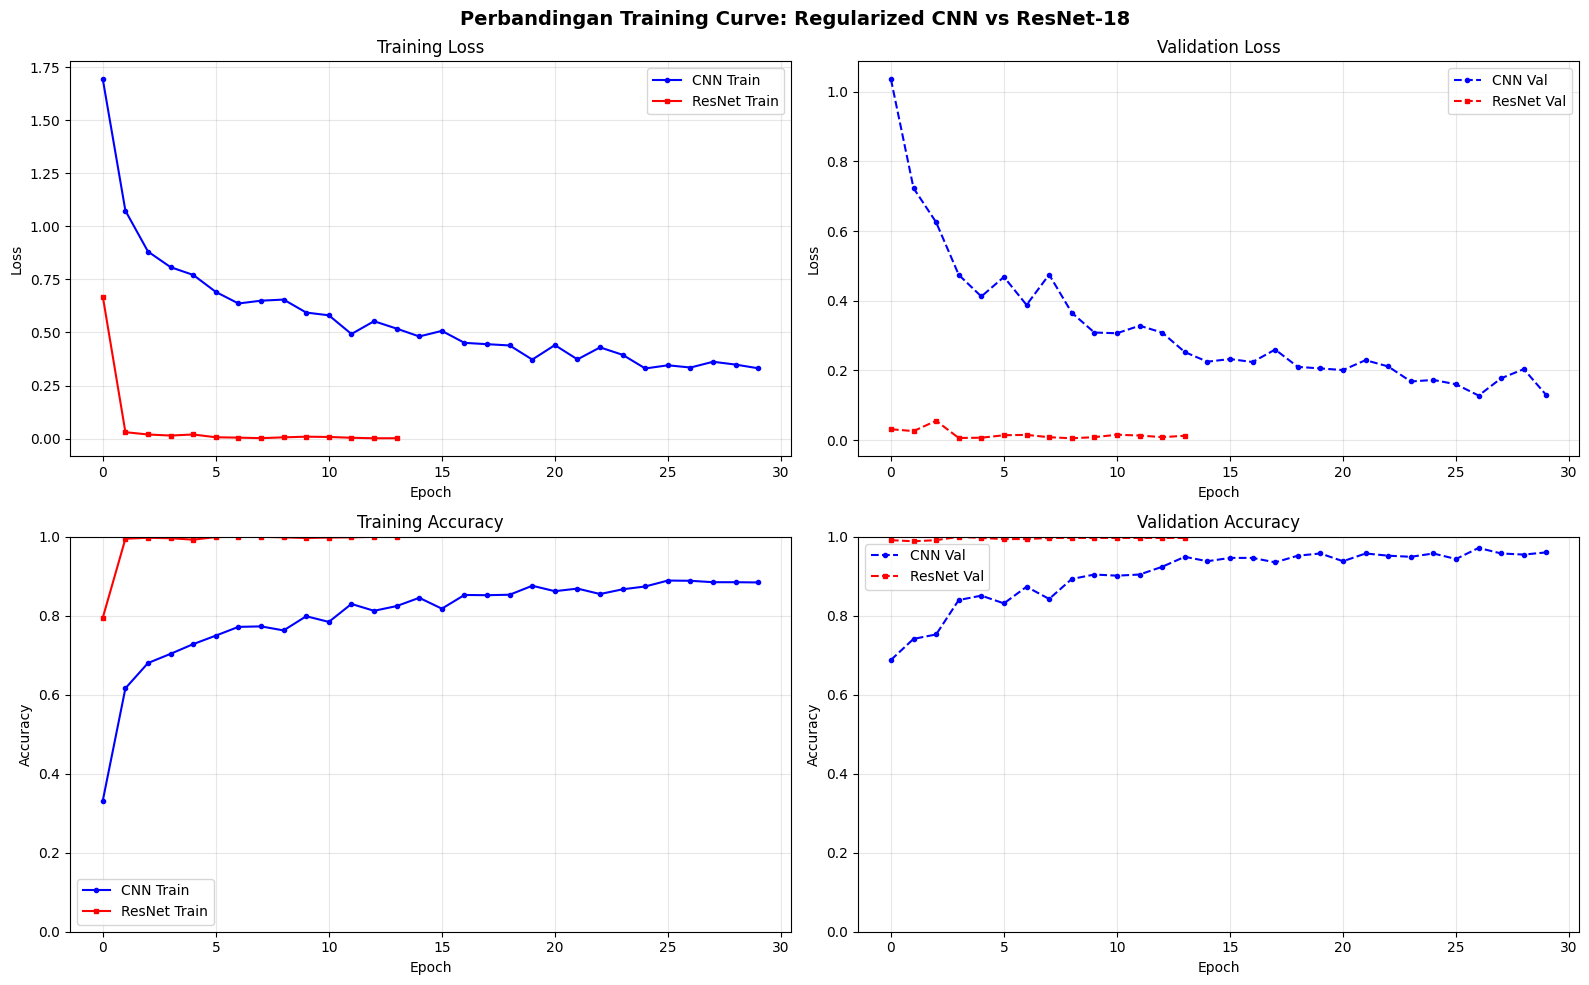


Training curve tersimpan di: /content/drive/MyDrive/Colab Notebooks/hasil_komparasi/training_curve_comparison.png


In [14]:
# ==============================================================================
# BLOK 14: VISUALISASI TRAINING CURVE PERBANDINGAN
# ==============================================================================
# Plot loss dan accuracy training/validasi kedua model dalam satu grafik
# untuk memudahkan perbandingan konvergensi dan overfitting behavior.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Perbandingan Training Curve: Regularized CNN vs ResNet-18',
             fontsize=14, fontweight='bold')

# ── PLOT 1: Training Loss (kiri atas) ─────────────────────────────────────────
axes[0, 0].plot(cnn_history['train_loss'],    label='CNN Train',    color='blue',   marker='o', markersize=3)
axes[0, 0].plot(resnet_history['train_loss'], label='ResNet Train', color='red',    marker='s', markersize=3)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ── PLOT 2: Validation Loss (kanan atas) ──────────────────────────────────────
axes[0, 1].plot(cnn_history['val_loss'],    label='CNN Val',    color='blue',   linestyle='--', marker='o', markersize=3)
axes[0, 1].plot(resnet_history['val_loss'], label='ResNet Val', color='red',    linestyle='--', marker='s', markersize=3)
axes[0, 1].set_title('Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── PLOT 3: Training Accuracy (kiri bawah) ────────────────────────────────────
axes[1, 0].plot(cnn_history['train_acc'],    label='CNN Train',    color='blue',   marker='o', markersize=3)
axes[1, 0].plot(resnet_history['train_acc'], label='ResNet Train', color='red',    marker='s', markersize=3)
axes[1, 0].set_title('Training Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ── PLOT 4: Validation Accuracy (kanan bawah) ─────────────────────────────────
axes[1, 1].plot(cnn_history['val_acc'],    label='CNN Val',    color='blue',   linestyle='--', marker='o', markersize=3)
axes[1, 1].plot(resnet_history['val_acc'], label='ResNet Val', color='red',    linestyle='--', marker='s', markersize=3)
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Simpan grafik ke Google Drive
curve_path = os.path.join(OUTPUT_DIR, 'training_curve_comparison.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTraining curve tersimpan di: {curve_path}")




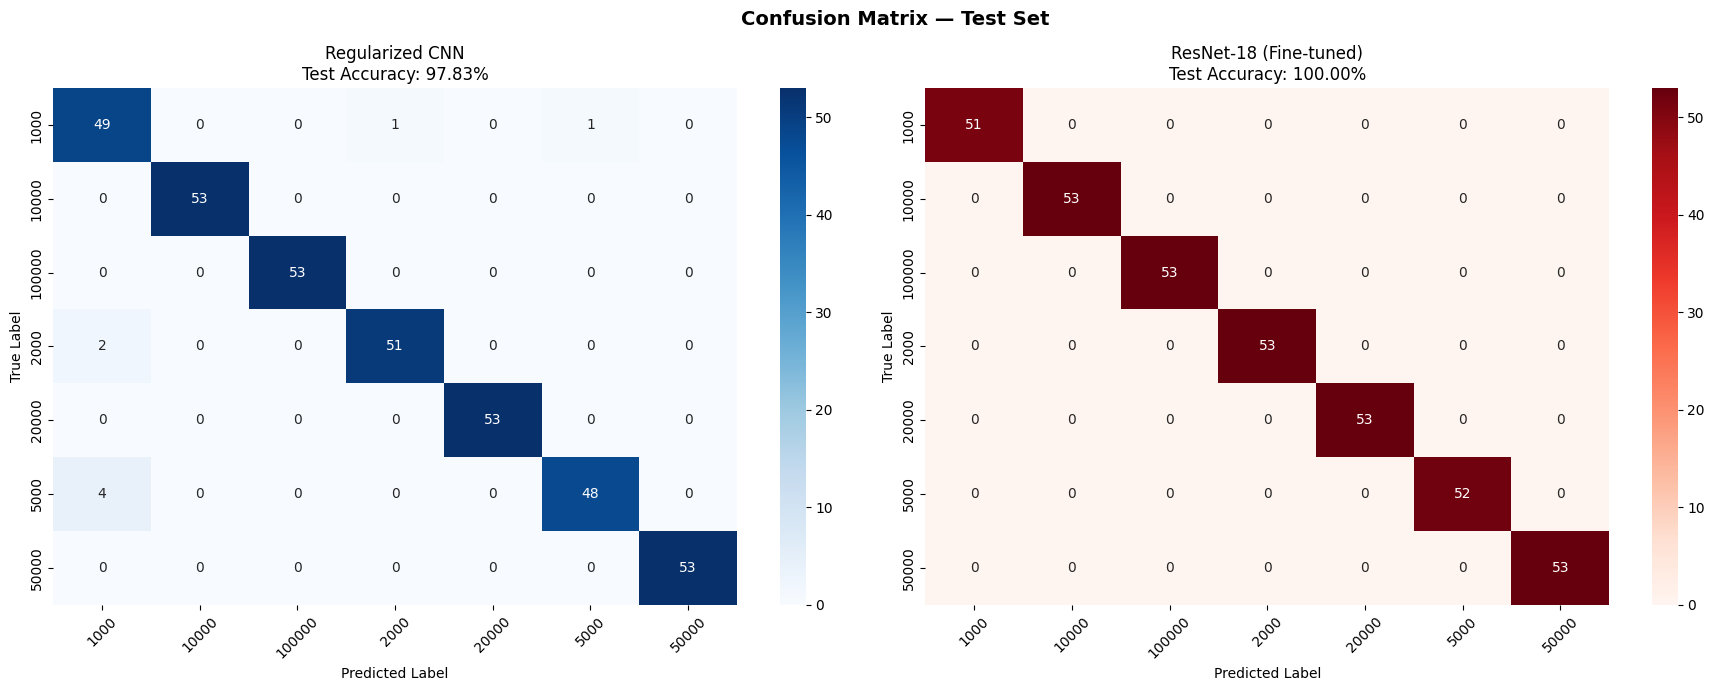


Confusion matrix tersimpan di: /content/drive/MyDrive/Colab Notebooks/hasil_komparasi/confusion_matrix_comparison.png


In [15]:
# ==============================================================================
# BLOK 15: CONFUSION MATRIX KEDUA MODEL
# ==============================================================================
# Visualisasi confusion matrix untuk melihat pola error prediksi per kelas
# pada test set masing-masing model.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')

# ── CONFUSION MATRIX CNN ──────────────────────────────────────────────────────
cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
sns.heatmap(
    cm_cnn,
    annot=True,               # Tampilkan angka di dalam cell
    fmt='d',                  # Format integer
    cmap='Blues',             # Colormap biru (semakin gelap = lebih banyak)
    xticklabels=CLASS_NAMES,  # Label sumbu X: kelas yang diprediksi
    yticklabels=CLASS_NAMES,  # Label sumbu Y: kelas sebenarnya
    ax=axes[0]
)
axes[0].set_title(f'Regularized CNN\nTest Accuracy: {cnn_test_acc*100:.2f}%')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=45)

# ── CONFUSION MATRIX RESNET-18 ────────────────────────────────────────────────
cm_resnet = confusion_matrix(resnet_labels, resnet_preds)
sns.heatmap(
    cm_resnet,
    annot=True,
    fmt='d',
    cmap='Reds',              # Colormap merah untuk membedakan dari CNN
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1]
)
axes[1].set_title(f'ResNet-18 (Fine-tuned)\nTest Accuracy: {resnet_test_acc*100:.2f}%')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

# Simpan confusion matrix ke Google Drive
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_comparison.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nConfusion matrix tersimpan di: {cm_path}")




In [16]:
# ==============================================================================
# BLOK 16: TABEL RINGKASAN PERBANDINGAN PERFORMA
# ==============================================================================
# Cetak tabel perbandingan komprehensif antara kedua model untuk referensi
# penulisan bagian Results & Discussion pada paper.

from sklearn.metrics import precision_score, recall_score, f1_score

# Hitung metrik macro-averaged untuk kedua model
cnn_precision    = precision_score(cnn_labels,    cnn_preds,    average='macro', zero_division=0)
cnn_recall       = recall_score(cnn_labels,       cnn_preds,    average='macro', zero_division=0)
cnn_f1           = f1_score(cnn_labels,           cnn_preds,    average='macro', zero_division=0)

resnet_precision = precision_score(resnet_labels, resnet_preds, average='macro', zero_division=0)
resnet_recall    = recall_score(resnet_labels,    resnet_preds, average='macro', zero_division=0)
resnet_f1        = f1_score(resnet_labels,        resnet_preds, average='macro', zero_division=0)

# ── TABEL PERBANDINGAN ────────────────────────────────────────────────────────
print("\n" + "="*70)
print("RINGKASAN PERBANDINGAN PERFORMA MODEL (TEST SET)")
print("="*70)
print(f"{'Metrik':<30} {'Regularized CNN':>17} {'ResNet-18':>17}")
print("-"*70)
print(f"{'Test Accuracy':<30} {cnn_test_acc:>16.4f} {resnet_test_acc:>17.4f}")
print(f"{'Macro Precision':<30} {cnn_precision:>16.4f} {resnet_precision:>17.4f}")
print(f"{'Macro Recall':<30} {cnn_recall:>16.4f} {resnet_recall:>17.4f}")
print(f"{'Macro F1-Score':<30} {cnn_f1:>16.4f} {resnet_f1:>17.4f}")
print("-"*70)
print(f"{'Jumlah Parameter':<30} {cnn_params:>16,} {resnet_params:>17,}")
print(f"{'Waktu Training (detik)':<30} {cnn_time:>16.1f} {resnet_time:>17.1f}")
print(f"{'Pretrained':<30} {'Tidak (from scratch)':>17} {'Ya (ImageNet)':>17}")
print("="*70)

# Tentukan model terbaik berdasarkan test accuracy
winner = 'Regularized CNN' if cnn_test_acc >= resnet_test_acc else 'ResNet-18'
print(f"\n>> Model dengan test accuracy tertinggi: {winner}")





RINGKASAN PERBANDINGAN PERFORMA MODEL (TEST SET)
Metrik                           Regularized CNN         ResNet-18
----------------------------------------------------------------------
Test Accuracy                            0.9783            1.0000
Macro Precision                          0.9788            1.0000
Macro Recall                             0.9780            1.0000
Macro F1-Score                           0.9781            1.0000
----------------------------------------------------------------------
Jumlah Parameter                        423,175        11,180,103
Waktu Training (detik)                    645.5             340.5
Pretrained                     Tidak (from scratch)     Ya (ImageNet)

>> Model dengan test accuracy tertinggi: ResNet-18


In [17]:
# ==============================================================================
# BLOK 17: SIMPAN MODEL FINAL (OPSIONAL)
# ==============================================================================
# Simpan model dalam format lengkap (state_dict + metadata) agar bisa
# di-load kembali tanpa mendefinisikan ulang arsitektur class.

# Simpan CNN final
cnn_final_path = os.path.join(OUTPUT_DIR, 'final_cnn_complete.pth')
torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'classes':          CLASS_NAMES,
    'num_classes':      NUM_CLASSES,
    'img_size':         IMG_SIZE,
    'architecture':     'RegularizedCNN',
    'test_accuracy':    cnn_test_acc,
    'transform':        val_test_transform,
}, cnn_final_path)

# Simpan ResNet-18 final
resnet_final_path = os.path.join(OUTPUT_DIR, 'final_resnet18_complete.pth')
torch.save({
    'model_state_dict': resnet_model.state_dict(),
    'classes':          CLASS_NAMES,
    'num_classes':      NUM_CLASSES,
    'img_size':         IMG_SIZE,
    'architecture':     'ResNet18-FineTuned',
    'test_accuracy':    resnet_test_acc,
    'transform':        val_test_transform,
}, resnet_final_path)

print(f"\nModel CNN final tersimpan    : {cnn_final_path}")
print(f"Model ResNet-18 final tersimpan: {resnet_final_path}")
print("\n" + "="*60)
print("EKSPERIMEN KOMPARASI SELESAI!")
print("="*60)



Model CNN final tersimpan    : /content/drive/MyDrive/Colab Notebooks/hasil_komparasi/final_cnn_complete.pth
Model ResNet-18 final tersimpan: /content/drive/MyDrive/Colab Notebooks/hasil_komparasi/final_resnet18_complete.pth

EKSPERIMEN KOMPARASI SELESAI!
